In [56]:
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
import os
import json
import warnings
warnings.filterwarnings("ignore")

In [57]:
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/models",    exist_ok=True)

load data dari csv hasil eda

In [58]:
df = pd.read_csv("data/raw/data_raw.csv")
print(f"data yang dimuat: {len(df):,} baris | {len(df.columns)} kolom")

data yang dimuat: 100,000 baris | 42 kolom


labeling berdasarkan eventid

In [59]:
print("eventid yang ada di dataset:")
eventid_counts = df["eventid"].value_counts()
eventid_tabel = eventid_counts.reset_index()
eventid_tabel.columns = ['eventid', 'jumlah']
eventid_tabel

eventid yang ada di dataset:


,eventid,jumlah
0,cowrie.session.connect,14976
1,cowrie.session.closed,14975
2,cowrie.login.failed,13224
3,cowrie.client.version,12766
4,cowrie.client.kex,12572
5,cowrie.command.input,9567
6,cowrie.session.params,5391
7,cowrie.log.closed,5374
8,cowrie.login.success,4909
9,cowrie.command.failed,3637


In [60]:
# definisi event yang termasuk anomali
ANOMALI_EVENTS = {
    "cowrie.login.failed",           # brute force gagal
    "cowrie.login.success",          # login berhasil di honeypot 
    "cowrie.command.input",          # eksekusi perintah shell
    "cowrie.session.file_download",  # unduh file malware
    "cowrie.direct-tcpip.request",   # port forwarding mencurigakan
    "cowrie.session.file_upload",    # upload file ke honeypot
}

def buat_label(eventid):
    return 1 if eventid in ANOMALI_EVENTS else 0

df["label"] = df["eventid"].apply(buat_label)

print(f"\ndistribusi label:")
print(df["label"].value_counts())
print(f"proporsi anomali : {df['label'].mean():.2%}")
print(f"proporsi normal  : {(1 - df['label'].mean()):.2%}")


distribusi label:
label
0    70289
1    29711
Name: count, dtype: int64
proporsi anomali : 29.71%
proporsi normal  : 70.29%


visualisasi distribusi label eventid

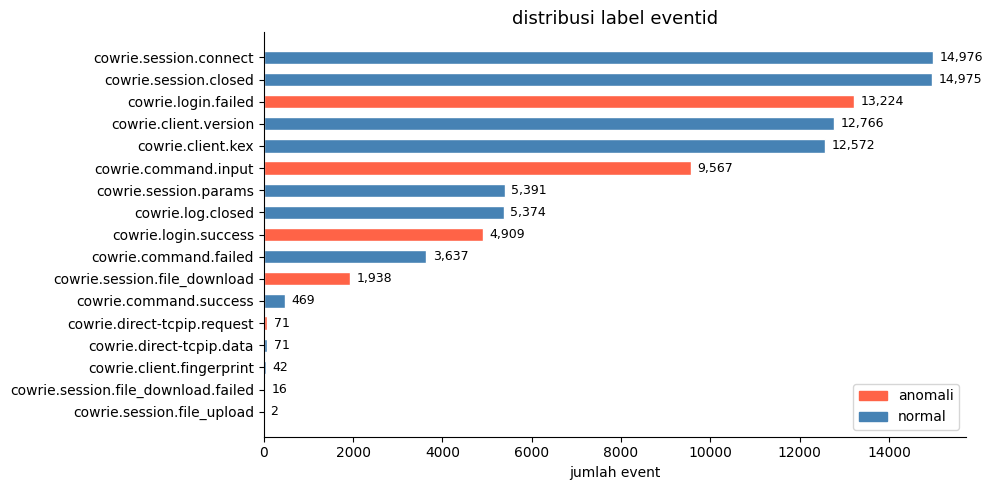

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [
    "tomato" if evt in ANOMALI_EVENTS else "steelblue"
    for evt in eventid_counts.index
]

ax.barh(
    eventid_counts.index,
    eventid_counts.values,
    color=bar_colors,
    edgecolor="white",
    height=0.6
)
for i, (val, evt) in enumerate(zip(eventid_counts.values, eventid_counts.index)):
    ax.text(val + eventid_counts.max() * 0.01, i, f"{val:,}", va="center", fontsize=9)

legend_handles = [
    mpatches.Patch(color="tomato", label="anomali"),
    mpatches.Patch(color="steelblue", label="normal"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)
ax.set_title("distribusi label eventid", fontsize=13)
ax.set_xlabel("jumlah event")
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("data/processed/distribusi_eventid.png", dpi=150, bbox_inches="tight")
plt.show()

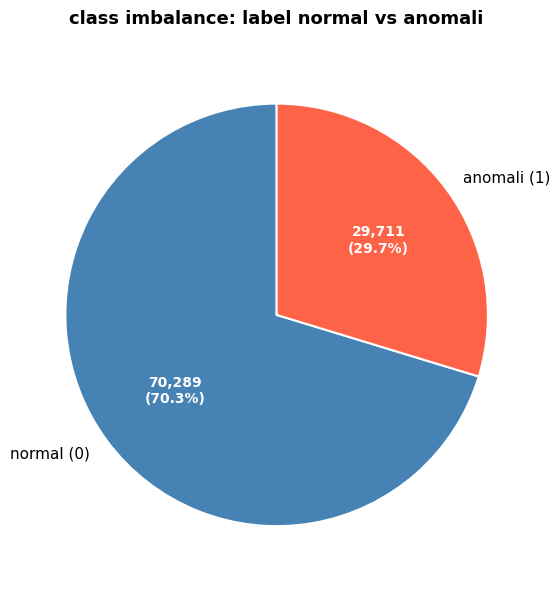

In [62]:
label_counts = df["label"].value_counts().sort_index() # data dari hasil df["label"].value_counts()

def hitung_label_dan_persen(pct):
    total = sum(label_counts.values)
    val = int(round(pct * total / 100.0))
    return f"{val:,}\n({pct:.1f}%)"

fig, ax = plt.subplots(figsize=(6, 6))

colors_label = ["steelblue", "tomato"] 

wedges, texts, autotexts = ax.pie(
    label_counts.values,
    labels=["normal (0)", "anomali (1)"],
    colors=colors_label,
    autopct=hitung_label_dan_persen,
    startangle=90,
    textprops=dict(fontsize=11),      
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(10)
    autotext.set_weight("bold")

ax.set_title("class imbalance: label normal vs anomali", fontsize=13, weight="bold", pad=20)
plt.tight_layout()
plt.savefig("data/processed/distribusi_label.png", dpi=150, bbox_inches="tight")
plt.show()

feature engineering

pembuatan fitur per event: indikator aktivitas berbahaya

In [63]:
df["has_command"]  = df["input"].notna().astype(int)   # 1 jika ada eksekusi perintah shell
df["has_download"] = df["url"].notna().astype(int)     # 1 jika ada unduhan file
df["has_upload"]   = df["outfile"].notna().astype(int) # 1 jika ada unggahan file
df["has_malware"]  = df["shasum"].notna().astype(int)  # 1 jika ada hash malware (file berbahaya)

df["duration"] = pd.to_numeric(df["duration"], errors="coerce").fillna(0)

df[["session", "eventid", "input", "url", "outfile", "shasum",
    "has_command", "has_download", "has_upload", "has_malware", "duration"]].head(5)

,session,eventid,input,url,outfile,shasum,has_command,has_download,has_upload,has_malware,duration
0,353d55b301f8,cowrie.session.connect,NaN,NaN,NaN,NaN,0,0,0,0,0.000000
1,353d55b301f8,cowrie.session.closed,NaN,NaN,NaN,NaN,0,0,0,0,39.703071
2,d2092f5e9efe,cowrie.session.connect,NaN,NaN,NaN,NaN,0,0,0,0,0.000000
3,d2092f5e9efe,cowrie.login.success,NaN,NaN,NaN,NaN,0,0,0,0,0.000000
4,d2092f5e9efe,cowrie.session.params,NaN,NaN,NaN,NaN,0,0,0,0,0.000000


pembuatan fitur agregasi per session aktivitas login

In [64]:
sess_login_fail = (
    df[df["eventid"] == "cowrie.login.failed"]
    .groupby("session").size()
    .reset_index(name="login_attempt_count")
)
sess_login_ok = (
    df[df["eventid"] == "cowrie.login.success"]
    .groupby("session").size()
    .reset_index(name="login_success_count")
)

df = df.merge(sess_login_fail, on="session", how="left")
df = df.merge(sess_login_ok,   on="session", how="left")
df["login_attempt_count"] = df["login_attempt_count"].fillna(0).astype(int)
df["login_success_count"] = df["login_success_count"].fillna(0).astype(int)

df[["session", "eventid", "login_attempt_count", "login_success_count"]].head(5)

,session,eventid,login_attempt_count,login_success_count
0,353d55b301f8,cowrie.session.connect,0,0
1,353d55b301f8,cowrie.session.closed,0,0
2,d2092f5e9efe,cowrie.session.connect,0,1
3,d2092f5e9efe,cowrie.login.success,0,1
4,d2092f5e9efe,cowrie.session.params,0,1


pembuatan fitur agregasi per session aktivitas perintah dan jumlah event

In [65]:
sess_cmd = (
    df[df["eventid"] == "cowrie.command.input"]
    .groupby("session").size()
    .reset_index(name="cmd_count")
)
sess_event_count = (
    df.groupby("session").size()
    .reset_index(name="session_event_count")
)

df = df.merge(sess_cmd,         on="session", how="left")
df = df.merge(sess_event_count, on="session", how="left")
df["cmd_count"]           = df["cmd_count"].fillna(0).astype(int)
df["session_event_count"] = df["session_event_count"].fillna(0).astype(int)

df[["session", "eventid", "cmd_count", "session_event_count"]].head(5)

,session,eventid,cmd_count,session_event_count
0,353d55b301f8,cowrie.session.connect,0,2
1,353d55b301f8,cowrie.session.closed,0,2
2,d2092f5e9efe,cowrie.session.connect,0,5
3,d2092f5e9efe,cowrie.login.success,0,5
4,d2092f5e9efe,cowrie.session.params,0,5


pembuatan fitur agregasi per session keragaman kredensial

In [66]:
sess_uniq_user = (
    df.groupby("session")["username"].nunique()
    .reset_index(name="unique_username_count")
)
sess_uniq_pass = (
    df.groupby("session")["password"].nunique()
    .reset_index(name="unique_password_count")
)

df = df.merge(sess_uniq_user, on="session", how="left")
df = df.merge(sess_uniq_pass, on="session", how="left")
df["unique_username_count"] = df["unique_username_count"].fillna(0).astype(int)
df["unique_password_count"] = df["unique_password_count"].fillna(0).astype(int)

df[["session", "username", "password",
    "unique_username_count", "unique_password_count"]].dropna(subset=["username"]).head(5)

,session,username,password,unique_username_count,unique_password_count
3,d2092f5e9efe,root,admin,1,1
8,a3a3c699036c,user,1234,1,3
9,a3a3c699036c,user,user,1,3
10,a3a3c699036c,user,123456,1,3
15,3c58fd2a5966,admin,admin,1,23


pembuatan fitur agregasi per ip skala aktivitas sumber

In [67]:
ip_total_events = (
    df.groupby("src_ip").size()
    .reset_index(name="ip_total_events")
)
ip_total_sessions = (
    df.groupby("src_ip")["session"].nunique()
    .reset_index(name="ip_total_sessions")
)

df = df.merge(ip_total_events,   on="src_ip", how="left")
df = df.merge(ip_total_sessions, on="src_ip", how="left")
df["ip_total_events"]   = df["ip_total_events"].fillna(0).astype(int)
df["ip_total_sessions"] = df["ip_total_sessions"].fillna(0).astype(int)

df[["src_ip", "session", "ip_total_events", "ip_total_sessions"]].head(5)

,src_ip,session,ip_total_events,ip_total_sessions
0,::ffff:112.11.222.190,353d55b301f8,122,61
1,::ffff:112.11.222.190,353d55b301f8,122,61
2,::ffff:149.50.103.48,d2092f5e9efe,20,4
3,::ffff:149.50.103.48,d2092f5e9efe,20,4
4,::ffff:149.50.103.48,d2092f5e9efe,20,4


fitur agregasi per ip riwayat login dan unduhan

In [68]:
ip_login_fail = (
    df[df["eventid"] == "cowrie.login.failed"]
    .groupby("src_ip").size()
    .reset_index(name="ip_total_login_fail")
)
ip_login_ok = (
    df[df["eventid"] == "cowrie.login.success"]
    .groupby("src_ip").size()
    .reset_index(name="ip_total_login_ok")
)
ip_downloads = (
    df[df["eventid"] == "cowrie.session.file_download"]
    .groupby("src_ip").size()
    .reset_index(name="ip_total_downloads")
)

df = df.merge(ip_login_fail, on="src_ip", how="left")
df = df.merge(ip_login_ok,   on="src_ip", how="left")
df = df.merge(ip_downloads,  on="src_ip", how="left")
df["ip_total_login_fail"] = df["ip_total_login_fail"].fillna(0).astype(int)
df["ip_total_login_ok"]   = df["ip_total_login_ok"].fillna(0).astype(int)
df["ip_total_downloads"]  = df["ip_total_downloads"].fillna(0).astype(int)

df[["src_ip", "ip_total_login_fail", "ip_total_login_ok", "ip_total_downloads"]].head(5)

,src_ip,ip_total_login_fail,ip_total_login_ok,ip_total_downloads
0,::ffff:112.11.222.190,0,0,0
1,::ffff:112.11.222.190,0,0,0
2,::ffff:149.50.103.48,0,4,0
3,::ffff:149.50.103.48,0,4,0
4,::ffff:149.50.103.48,0,4,0


encoding kolom protocol

In [69]:
df["protocol"] = df["protocol"].fillna("unknown").astype(str)

le_protocol = LabelEncoder()
df["protocol_encoded"] = le_protocol.fit_transform(df["protocol"])

joblib.dump(le_protocol, "data/models/label_encoder_protocol.pkl")
print(f"kelas protocol yang dikenali: {le_protocol.classes_}")

df[["session", "protocol", "protocol_encoded"]].head(5)

kelas protocol yang dikenali: ['ssh' 'telnet' 'unknown']


,session,protocol,protocol_encoded
0,353d55b301f8,telnet,1
1,353d55b301f8,unknown,2
2,d2092f5e9efe,telnet,1
3,d2092f5e9efe,unknown,2
4,d2092f5e9efe,unknown,2


fitur final

In [70]:
FITUR_SEMUA = [
    "src_port",              # port sumber koneksi
    "dst_port",              # port tujuan (biasanya 22 untuk SSH)
    "duration",              # durasi sesi dalam detik
    "protocol_encoded",      # protokol komunikasi (hasil encoding)
    "login_attempt_count",   # jumlah login gagal per sesi
    "login_success_count",   # jumlah login berhasil per sesi
    "cmd_count",             # jumlah perintah shell per sesi
    "session_event_count",   # total event per sesi
    "unique_username_count", # jumlah username unik per sesi
    "unique_password_count", # jumlah password unik per sesi
    "ip_total_events",       # total event dari IP ini
    "ip_total_sessions",     # total sesi dari IP ini
    "ip_total_login_fail",   # total login gagal dari IP ini
    "ip_total_login_ok",     # total login berhasil dari IP ini
    "ip_total_downloads",    # total unduhan dari IP ini
    "has_command",           # 1 jika ada eksekusi perintah
    "has_download",          # 1 jika ada unduhan file
    "has_upload",            # 1 jika ada unggahan file
    "has_malware",           # 1 jika terdeteksi hash malware
]
TARGET = "label"

# pastikan semua fitur bertipe numerik dan tidak ada nilai kosong
for col in FITUR_SEMUA:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print(f"total fitur yang digunakan: {len(FITUR_SEMUA)}")
print(f"\nmissing values setelah handling:")
print(df[FITUR_SEMUA].isnull().sum())

df[FITUR_SEMUA].head(5)

total fitur yang digunakan: 19

missing values setelah handling:
src_port                 0
dst_port                 0
duration                 0
protocol_encoded         0
login_attempt_count      0
login_success_count      0
cmd_count                0
session_event_count      0
unique_username_count    0
unique_password_count    0
ip_total_events          0
ip_total_sessions        0
ip_total_login_fail      0
ip_total_login_ok        0
ip_total_downloads       0
has_command              0
has_download             0
has_upload               0
has_malware              0
dtype: int64


,src_port,dst_port,duration,protocol_encoded,login_attempt_count,login_success_count,cmd_count,session_event_count,unique_username_count,unique_password_count,ip_total_events,ip_total_sessions,ip_total_login_fail,ip_total_login_ok,ip_total_downloads,has_command,has_download,has_upload,has_malware
0,54799.0,23.0,0.000000,1,0,0,0,2,0,0,122,61,0,0,0,0,0,0,0
1,0.0,0.0,39.703071,2,0,0,0,2,0,0,122,61,0,0,0,0,0,0,0
2,47838.0,23.0,0.000000,1,0,1,0,5,1,1,20,4,0,4,0,0,0,0,0
3,0.0,0.0,0.000000,2,0,1,0,5,1,1,20,4,0,4,0,0,0,0,0
4,0.0,0.0,0.000000,2,0,1,0,5,1,1,20,4,0,4,0,0,0,0,0


buat dataframe model

In [71]:
df_model = df[FITUR_SEMUA + [TARGET]].copy()
print(f"shape sebelum drop NA: {df_model.shape}")
df_model = df_model.dropna()
print(f"shape setelah drop NA: {df_model.shape}")

# hapus duplikat hanya berdasarkan subset fitur, bukan label 
# untuk mencegah kehilangan sampel anomali yang sudah sedikit
n_sebelum = len(df_model)
df_model = df_model.drop_duplicates(subset=FITUR_SEMUA, keep='first')
n_sesudah = len(df_model)
print(f"shape setelah drop duplikat (subset fitur): {df_model.shape}")
print(f"  (dihapus: {n_sebelum - n_sesudah:,} baris)")

print(f"\ndistribusi label final:")
print(df_model[TARGET].value_counts())
print(f"proporsi anomali: {df_model[TARGET].mean():.4%}")

shape sebelum drop NA: (100000, 20)
shape setelah drop NA: (100000, 20)
shape setelah drop duplikat (subset fitur): (37001, 20)
  (dihapus: 62,999 baris)

distribusi label final:
label
0    36257
1      744
Name: count, dtype: int64
proporsi anomali: 2.0108%


split data (80% train dan 20% test)

In [72]:
X = df_model[FITUR_SEMUA]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y.values,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train distribusi: {pd.Series(y_train).value_counts().to_dict()}")
print(f"y_test  distribusi: {pd.Series(y_test).value_counts().to_dict()}")

X_train : (29600, 19)
X_test  : (7401, 19)
y_train distribusi: {0: 29005, 1: 595}
y_test  distribusi: {0: 7252, 1: 149}


normalisasi fitur dengan standarscaler

In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# simpan scaler
joblib.dump(scaler, "data/models/scaler.pkl")

X_train_scaled
X_test_scaled

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FITUR_SEMUA)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FITUR_SEMUA)

In [74]:
# Statistik deskriptif data hasil scaling
print("=== Statistik Deskriptif - X_train_scaled ===")
X_train_scaled_df.describe()

=== Statistik Deskriptif - X_train_scaled ===


,src_port,dst_port,duration,protocol_encoded,login_attempt_count,login_success_count,cmd_count,session_event_count,unique_username_count,unique_password_count,ip_total_events,ip_total_sessions,ip_total_login_fail,ip_total_login_ok,ip_total_downloads,has_command,has_download,has_upload,has_malware
count,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,2.960000e+04,29600.000000,2.960000e+04,2.960000e+04
mean,-5.473099e-17,-1.606823e-17,1.104222e-17,-4.800964e-17,6.961398e-18,-3.984800e-17,-3.840772e-18,-7.861579e-17,-6.241254e-18,1.536309e-17,-1.440289e-17,7.681543e-18,-2.064415e-17,-6.193244e-17,-2.472497e-17,5.737152e-17,0.000000,-1.536309e-17,6.961398e-17
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017,1.000017e+00,1.000017e+00
min,-7.865256e-01,-2.118828e-01,-2.558006e-01,-1.316921e+00,-4.025295e-01,-8.752168e-01,-4.155083e-01,-8.800911e-01,-1.350109e+00,-6.292726e-01,-8.018228e-01,-6.867806e-01,-5.653093e-01,-1.031903e+00,-9.824649e-01,-1.027099e-01,-0.010068,-4.544300e-02,-4.121505e-01
25%,-7.865256e-01,-2.118828e-01,-2.558006e-01,-1.316921e+00,-4.025295e-01,-8.752168e-01,-4.155083e-01,-4.218857e-01,4.774423e-02,-1.417708e-01,-5.398802e-01,-5.026363e-01,-3.736376e-01,-9.759604e-01,-9.824649e-01,-1.027099e-01,-0.010068,-4.544300e-02,-4.121505e-01
50%,-7.865256e-01,-2.118828e-01,-2.460062e-01,8.023525e-01,-4.025295e-01,-8.752168e-01,-4.155083e-01,-4.218857e-01,4.774423e-02,-1.417708e-01,-6.748810e-02,-8.524262e-02,-1.229901e-01,8.694506e-02,-7.603169e-03,-1.027099e-01,-0.010068,-4.544300e-02,-4.121505e-01
75%,1.027156e+00,2.940281e-01,-1.247091e-01,8.023525e-01,4.588694e-02,1.142574e+00,2.325774e-01,4.945252e-01,4.774423e-02,-1.417708e-01,1.340062e-01,3.752022e-02,-1.229901e-01,5.344842e-01,9.672586e-01,-1.027099e-01,-0.010068,-4.544300e-02,-4.121505e-01
max,1.913433e+00,1.659799e+02,1.130300e+01,8.023525e-01,1.035947e+01,1.142574e+00,5.741305e+00,6.222093e+00,1.262842e+01,1.058327e+01,4.943003e+00,5.009415e+00,5.066888e+00,3.555373e+00,2.777716e+00,9.736164e+00,99.326062,2.200559e+01,2.426298e+00


In [75]:

print("\n=== Statistik Deskriptif - X_test_scaled ===")
X_test_scaled_df.describe()


=== Statistik Deskriptif - X_test_scaled ===


,src_port,dst_port,duration,protocol_encoded,login_attempt_count,login_success_count,cmd_count,session_event_count,unique_username_count,unique_password_count,ip_total_events,ip_total_sessions,ip_total_login_fail,ip_total_login_ok,ip_total_downloads,has_command,has_download,has_upload,has_malware
count,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7401.000000,7.401000e+03,7401.000000,7401.000000
mean,-0.031972,0.032183,-0.023003,0.029925,-0.005068,0.012491,0.001268,0.010797,-0.022139,-0.003905,-0.005626,-0.004288,0.000777,-0.009641,-0.009052,-0.006993,-1.006785e-02,0.020105,0.031968
std,0.987908,2.742242,0.878765,0.992980,1.024477,1.001658,1.005633,1.019762,0.954109,1.022453,1.011266,1.009623,1.010741,1.008177,1.003303,0.965768,3.469681e-18,1.200544,1.031267
min,-0.786526,-0.211883,-0.255801,-1.316921,-0.402530,-0.875217,-0.415508,-0.765540,-1.350109,-0.629273,-0.801823,-0.686781,-0.565309,-1.031903,-0.982465,-0.102710,-1.006785e-02,-0.045443,-0.412150
25%,-0.786526,-0.211883,-0.255801,-1.316921,-0.402530,-0.875217,-0.415508,-0.421886,0.047744,-0.141771,-0.542119,-0.527189,-0.388382,-0.975960,-0.982465,-0.102710,-1.006785e-02,-0.045443,-0.412150
50%,-0.786526,-0.211883,-0.244641,0.802353,-0.402530,-0.875217,-0.415508,-0.421886,0.047744,-0.141771,-0.067488,-0.085243,-0.122990,0.086945,-0.007603,-0.102710,-1.006785e-02,-0.045443,-0.412150
75%,0.964846,0.294028,-0.127408,0.802353,0.045887,1.142574,0.232577,0.494525,0.047744,-0.141771,0.134006,0.037520,-0.122990,0.534484,0.967259,-0.102710,-1.006785e-02,-0.045443,-0.412150
max,1.905603,165.979861,11.171035,0.802353,10.359466,1.142574,5.741305,6.222093,12.628421,10.583270,4.943003,5.009415,5.066888,3.555373,2.777716,9.736164,-1.006785e-02,22.005588,2.426298


simpan semua data

In [76]:
# simpan data lengkap hasil processed
X_scaled = scaler.transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FITUR_SEMUA)
df_processed = X_scaled_df.copy()
df_processed["label"] = y.values
df_processed.to_csv("data/processed/data_processed.csv", index=False)

In [77]:
# simpan train & test set
pd.DataFrame(X_train, columns=FITUR_SEMUA).assign(label=y_train)\
  .to_csv("data/processed/train_set.csv", index=False)
pd.DataFrame(X_test, columns=FITUR_SEMUA).assign(label=y_test)\
  .to_csv("data/processed/test_set.csv",  index=False)
pd.DataFrame(X_train_scaled, columns=FITUR_SEMUA).assign(label=y_train)\
  .to_csv("data/processed/train_set_scaled.csv", index=False)
pd.DataFrame(X_test_scaled, columns=FITUR_SEMUA).assign(label=y_test)\
  .to_csv("data/processed/test_set_scaled.csv", index=False)

In [78]:
# simpan nama fitur untuk dipakai di pipeline Flink
with open("data/models/fitur_names.json", "w") as f:
    json.dump({"fitur": FITUR_SEMUA, "target": TARGET}, f, indent=2)